# 01 · Data Exploration

Explore the PlantVillage dataset: class distribution, sample images, image properties. Before training anything, we sanity-check what we're working with.

## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from PIL import Image
from torchvision import datasets

In [2]:
# Point to your downloaded PlantVillage 'color' folder
DATA_DIR = '../data/plantvillage/color'
ds = datasets.ImageFolder(DATA_DIR)
print(f'Total images: {len(ds)}')
print(f'Number of classes: {len(ds.classes)}')
print(f'First 5 classes: {ds.classes[:5]}')

Total images: 54305
Number of classes: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## Class distribution

Check whether the dataset is balanced. Imbalanced classes matter for:
- Whether to use weighted loss
- Interpreting per-class accuracy
- How to stratify our baseline random guesser

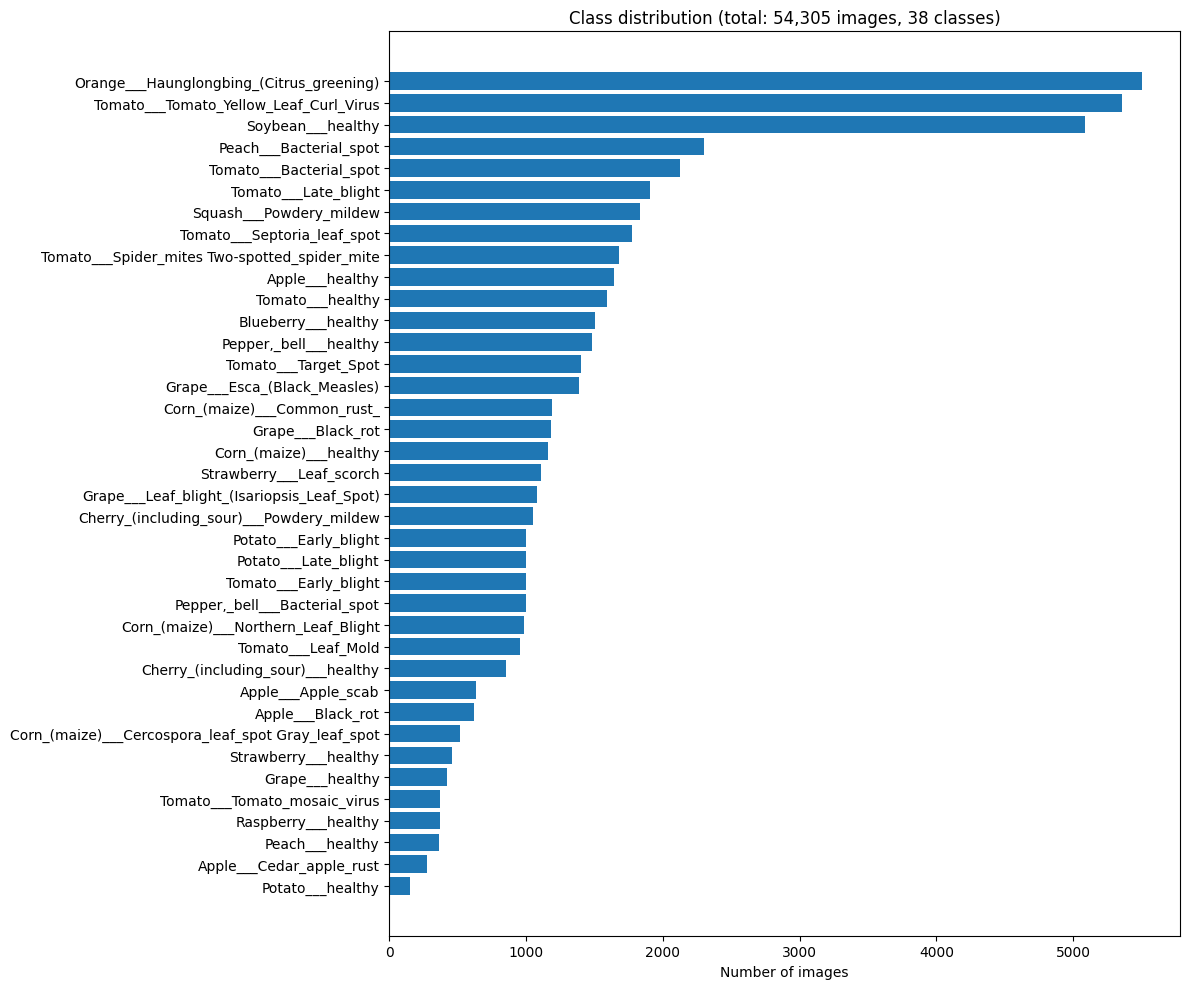

Min class size: 152 (Potato___healthy)
Max class size: 5507 (Orange___Haunglongbing_(Citrus_greening))
Imbalance ratio: 36.2x


In [3]:
labels = [label for _, label in ds.samples]
counts = Counter(labels)
counts_by_class = [(ds.classes[i], c) for i, c in counts.items()]
counts_by_class.sort(key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(12, 10))
names = [c[0] for c in counts_by_class]
vals = [c[1] for c in counts_by_class]
ax.barh(names, vals)
ax.set_xlabel('Number of images')
ax.set_title(f'Class distribution (total: {sum(vals):,} images, {len(names)} classes)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Min class size: {min(vals)} ({names[-1]})')
print(f'Max class size: {max(vals)} ({names[0]})')
print(f'Imbalance ratio: {max(vals)/min(vals):.1f}x')

## Sample images

One representative image per class — useful for sanity-checking labels.

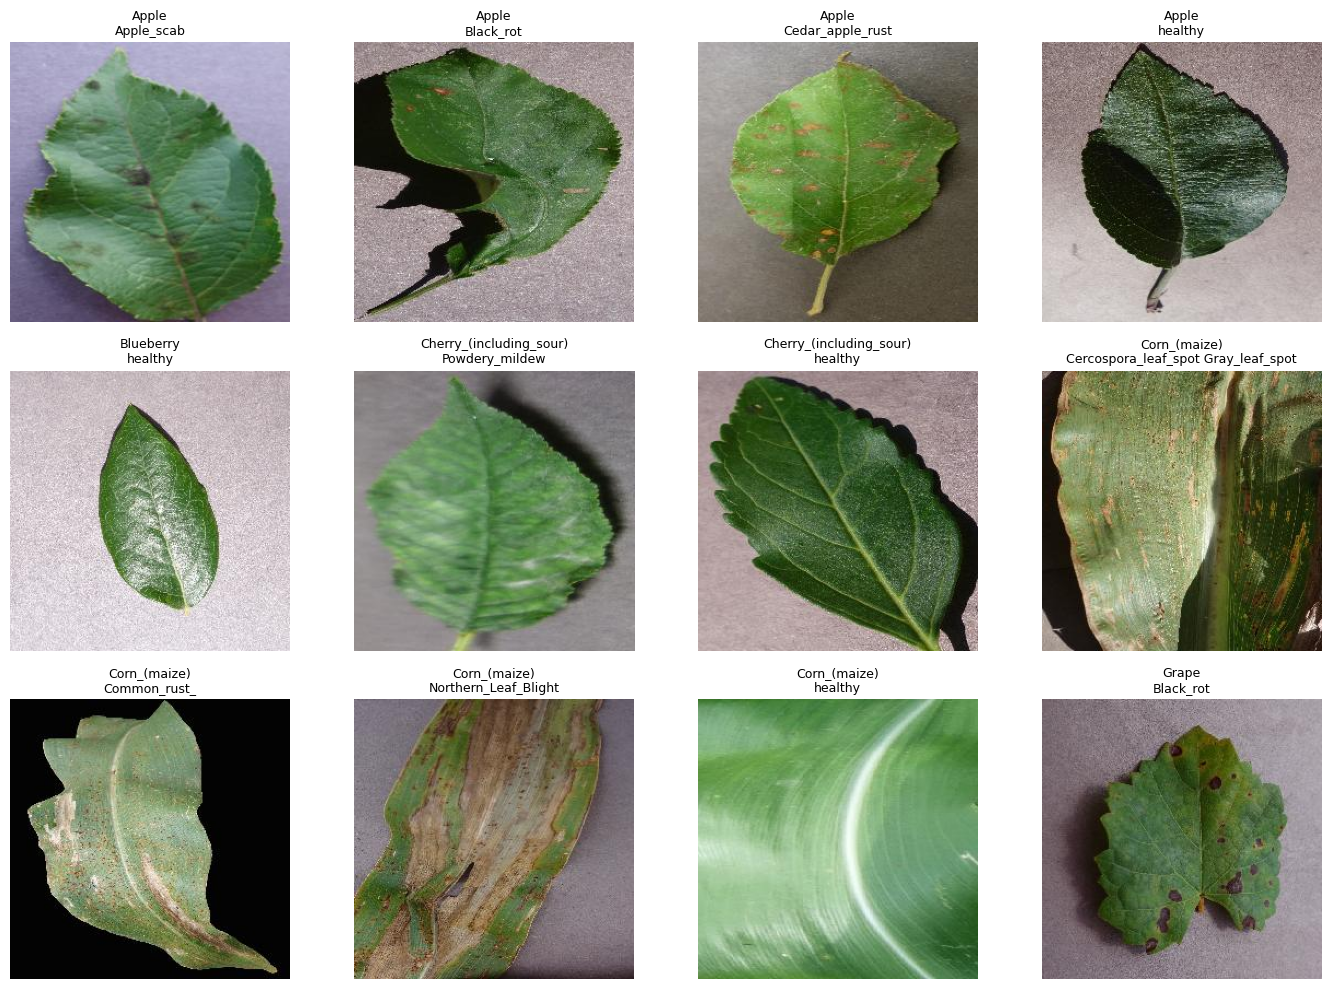

In [4]:
classes_to_show = ds.classes[:12]  # first 12 classes
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, cls in zip(axes.flat, classes_to_show):
    idx = next(i for i, (_, lbl) in enumerate(ds.samples) if lbl == ds.class_to_idx[cls])
    img, _ = ds[idx]
    ax.imshow(img)
    ax.set_title(cls.replace('___', '\n'), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Image size stats

Everything should be 256×256 in the color subset, but let's verify.

In [5]:
sample_sizes = []
for path, _ in ds.samples[:500]:
    with Image.open(path) as img:
        sample_sizes.append(img.size)

widths = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]
print(f'Width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')

Width: min=256, max=256, mean=256
Height: min=256, max=256, mean=256


## Takeaways

- Dataset is ~87k images across 38 classes
- Class imbalance is moderate — worth noting but not catastrophic
- All images are 256×256; we'll resize to 224×224 for ResNet-50
- Images are clean, foreground leaves on mostly neutral backgrounds — good training conditions